# QoS Buddy Diagnostic Agent - 8 Root-Cause Deployment Benchmark

This notebook builds on the revised validation report and turns the validated modeling stack into a deployment-oriented benchmark:

- **Random Forest** for first-pass 8-way root-cause diagnosis from engineered QoS/RAN/router KPIs.
- **GRU autoencoder** for 10-sample temporal representation.
- **FAISS-compatible prototype retrieval** over a GRU-latent + Random-Forest-posterior hybrid vector for similar-case evidence.

The revised report validated a strict 2-class real-data benchmark (`RC_CAPACITY_OVERLOAD`, `RC_TRANSPORT_DELAY`) and selected the model families above. This notebook extends that foundation to the 8 deployment contracts required by the Diagnostic Agent. The extension is explicit: every augmented record is marked, generated by a bounded root-cause contract, and separated from real observed labels in the reporting.

## Design Rules

1. Do not use hidden Kaggle artifacts. Everything is rebuilt from the local `data/*.csv` files.
2. Do not train on shortcut/leaky fields such as `anomaly_flag`, `anomaly_score`, `baseline_phase`, `traffic_confidence`, data-completeness fields, or split metadata.
3. Preserve chronological train/validation/test splitting with purge gaps before augmentation.
4. Use controlled augmentation only to cover root-cause contracts that are rare or missing in the observed data.
5. Save deployable artifacts: feature list, contracts, label encoder, Random Forest model, GRU weights/scalers, prototype vectors, and FAISS index when the runtime supports FAISS.

In [1]:
import json
import math
import os
import random
import time
import warnings
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs_8rc")
OUTPUT_DIR.mkdir(exist_ok=True)

WINDOW_SIZE = 10
CONTRACT_EPISODE_LENGTH = 40
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
PURGE_ROWS = 10

TARGET_COUNTS = {
    "train": 320,
    "val": 80,
    "test": 80,
}

RF_N_ESTIMATORS = 500
GRU_EPOCHS = 18
GRU_PATIENCE = 5
GRU_BATCH_SIZE = 96


def log(message: str):
    print(f"[INFO] {message}")


def banner(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)


banner("Notebook initialized")
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


Notebook initialized
Data directory: C:\Users\amani\OneDrive\Desktop\Diagnostic agent\Diagnostic agent notebooks+report\data
Output directory: C:\Users\amani\OneDrive\Desktop\Diagnostic agent\Diagnostic agent notebooks+report\outputs_8rc


## 1. Root-Cause Contracts

The observed anomaly types do not naturally cover all deployment root causes with enough examples. The table below defines the 8 root-cause contracts that the Diagnostic Agent must emit. Real labels are used when available; missing and rare contracts are filled using bounded KPI transformations that reflect the operational meaning of each root cause.

In [2]:
ROOT_CAUSE_CONTRACTS = {
    "RC_CAPACITY_OVERLOAD": {
        "real_anomaly_types": ["low_throughput", "congestion"],
        "description": "Capacity or congestion pressure: low throughput, high queueing, high utilization, and connection pressure.",
        "primary_evidence": ["throughput_mbps", "bandwidth_util_pct", "queue_length", "active_connections"],
        "augmentation": "Boost utilization/queue/connection pressure and reduce throughput within operational bounds.",
    },
    "RC_TRANSPORT_DELAY": {
        "real_anomaly_types": ["high_latency", "latency_degradation"],
        "description": "Transport/path delay: sustained latency increase with queue pressure and degraded MOS.",
        "primary_evidence": ["latency_ms", "queue_length", "mos_estimate", "jitter_ms"],
        "augmentation": "Raise latency and queueing while keeping the signature distinct from pure jitter or packet loss.",
    },
    "RC_JITTER_INSTABILITY": {
        "real_anomaly_types": ["jitter_degradation", "high_jitter"],
        "description": "Unstable delay variation: jitter spikes dominate the QoS failure.",
        "primary_evidence": ["jitter_ms", "jitter_increasing", "latency_volatility"],
        "augmentation": "Raise jitter and jitter trend, with moderate latency impact.",
    },
    "RC_PACKET_LOSS": {
        "real_anomaly_types": ["severe_packet_loss"],
        "description": "Packet loss path degradation: packet loss and BLER/retransmission pressure dominate.",
        "primary_evidence": ["packet_loss_pct", "tcp_retransmit_rate", "bler_proxy_pct", "mos_estimate"],
        "augmentation": "Raise packet loss and retransmission pressure and reduce MOS/throughput.",
    },
    "RC_RETRANSMISSION": {
        "real_anomaly_types": ["high_retransmission"],
        "description": "Transport retransmission pressure without necessarily severe packet loss.",
        "primary_evidence": ["tcp_retransmit_rate", "bler_proxy_pct", "throughput_mbps"],
        "augmentation": "Raise retransmission/BLER with low-to-moderate packet loss.",
    },
    "RC_RADIO_SIGNAL_WEAK": {
        "real_anomaly_types": ["weak_signal"],
        "description": "Weak radio/Wi-Fi signal: poor RSSI/RSRP and low signal-health scores.",
        "primary_evidence": ["rssi_dbm", "rsrp_dbm", "signal_health_score", "wifi_signal_score", "cellular_signal_score"],
        "augmentation": "Push signal metrics into weak ranges and degrade throughput modestly.",
    },
    "RC_HANDOVER_INSTABILITY": {
        "real_anomaly_types": [],
        "description": "Mobility/handover instability: repeated handovers, low handover success, and latency/jitter spikes.",
        "primary_evidence": ["handover_event", "handover_count", "ho_success_rate_pct", "cssr_proxy_pct"],
        "augmentation": "Synthesize handover events with low success rate and transient latency/jitter impact.",
    },
    "RC_CQI_MISMATCH": {
        "real_anomaly_types": [],
        "description": "CQI/MCS/BLER mismatch: radio quality indicators conflict with selected modulation/coding behavior.",
        "primary_evidence": ["cqi", "mcs", "sinr_db", "bler_proxy_pct", "bler_mcs_stress"],
        "augmentation": "Create inconsistent CQI/MCS/BLER patterns while keeping signal levels plausible.",
    },
}

ANOMALY_TO_ROOT_CAUSE = {
    anomaly_type: root_cause
    for root_cause, spec in ROOT_CAUSE_CONTRACTS.items()
    for anomaly_type in spec["real_anomaly_types"]
}

contracts_df = (
    pd.DataFrame.from_dict(ROOT_CAUSE_CONTRACTS, orient="index")
    .reset_index()
    .rename(columns={"index": "root_cause"})
)
display(contracts_df)

with open(OUTPUT_DIR / "root_cause_contracts_8rc.json", "w", encoding="utf-8") as f:
    json.dump(ROOT_CAUSE_CONTRACTS, f, indent=2)

,root_cause,real_anomaly_types,description,primary_evidence,augmentation
0,RC_CAPACITY_OVERLOAD,"[low_throughput, congestion]",Capacity or congestion pressure: low throughpu...,"[throughput_mbps, bandwidth_util_pct, queue_le...",Boost utilization/queue/connection pressure an...
1,RC_TRANSPORT_DELAY,"[high_latency, latency_degradation]",Transport/path delay: sustained latency increa...,"[latency_ms, queue_length, mos_estimate, jitte...",Raise latency and queueing while keeping the s...
2,RC_JITTER_INSTABILITY,"[jitter_degradation, high_jitter]",Unstable delay variation: jitter spikes domina...,"[jitter_ms, jitter_increasing, latency_volatil...","Raise jitter and jitter trend, with moderate l..."
3,RC_PACKET_LOSS,[severe_packet_loss],Packet loss path degradation: packet loss and ...,"[packet_loss_pct, tcp_retransmit_rate, bler_pr...",Raise packet loss and retransmission pressure ...
4,RC_RETRANSMISSION,[high_retransmission],Transport retransmission pressure without nece...,"[tcp_retransmit_rate, bler_proxy_pct, throughp...",Raise retransmission/BLER with low-to-moderate...
5,RC_RADIO_SIGNAL_WEAK,[weak_signal],Weak radio/Wi-Fi signal: poor RSSI/RSRP and lo...,"[rssi_dbm, rsrp_dbm, signal_health_score, wifi...",Push signal metrics into weak ranges and degra...
6,RC_HANDOVER_INSTABILITY,[],Mobility/handover instability: repeated handov...,"[handover_event, handover_count, ho_success_ra...",Synthesize handover events with low success ra...
7,RC_CQI_MISMATCH,[],CQI/MCS/BLER mismatch: radio quality indicator...,"[cqi, mcs, sinr_db, bler_proxy_pct, bler_mcs_s...",Create inconsistent CQI/MCS/BLER patterns whil...


## 2. Load Local QoS Time-Series Data

In [3]:
def parse_choice_date(path: Path):
    stem = path.stem
    parts = stem.split("_")
    choice = None
    date = None
    for i, part in enumerate(parts):
        if part == "choice" and i + 2 < len(parts):
            choice = parts[i + 1]
            date = parts[i + 2]
            break
    return choice, date


def load_qos_files(data_dir: Path) -> pd.DataFrame:
    frames = []
    for path in sorted(data_dir.glob("qos_timeseries_*.csv")):
        df = pd.read_csv(path)
        choice, date = parse_choice_date(path)
        df["source_file"] = path.name
        df["collection_choice"] = choice
        df["collection_date"] = date
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No qos_timeseries_*.csv files found in {data_dir.resolve()}")
    out = pd.concat(frames, ignore_index=True, sort=False)
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
    out = out.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    out["row_id"] = np.arange(len(out))
    out["root_cause_label"] = out["anomaly_type"].map(ANOMALY_TO_ROOT_CAUSE)
    out["is_real_labeled"] = out["root_cause_label"].notna()
    out["sequence_group"] = (
        out["source_file"].astype(str)
        + "|"
        + out.get("node_id", "node").astype(str)
        + "|real"
    )
    return out


raw_df = load_qos_files(DATA_DIR)

banner("Loaded local QoS data")
print(raw_df.shape)
display(raw_df[["timestamp", "source_file", "anomaly_type", "root_cause_label", "is_real_labeled"]].head())
display(raw_df["anomaly_type"].value_counts(dropna=False).rename("rows").to_frame())
display(raw_df["root_cause_label"].value_counts(dropna=False).rename("rows").to_frame())


Loaded local QoS data
(3128, 89)


,timestamp,source_file,anomaly_type,root_cause_label,is_real_labeled
0,2026-03-27 17:22:08.968812,qos_timeseries_choice_11_20260327.csv,low_throughput,RC_CAPACITY_OVERLOAD,True
1,2026-03-27 17:23:28.364780,qos_timeseries_choice_11_20260327.csv,normal,NaN,False
2,2026-03-27 17:24:37.526631,qos_timeseries_choice_11_20260327.csv,low_throughput,RC_CAPACITY_OVERLOAD,True
3,2026-03-27 17:26:00.814790,qos_timeseries_choice_11_20260327.csv,normal,NaN,False
4,2026-03-27 17:27:10.013727,qos_timeseries_choice_11_20260327.csv,low_throughput,RC_CAPACITY_OVERLOAD,True


,rows
anomaly_type,
weak_signal,1435
normal,1012
severe_packet_loss,203
latency_degradation,103
high_latency,100
jitter_degradation,100
low_throughput,82
high_retransmission,53
high_jitter,19


,rows
root_cause_label,
RC_RADIO_SIGNAL_WEAK,1435
NaN,1020
RC_TRANSPORT_DELAY,203
RC_PACKET_LOSS,203
RC_JITTER_INSTABILITY,119
RC_CAPACITY_OVERLOAD,95
RC_RETRANSMISSION,53


## 3. Chronological Split With Purge Gap

In [4]:
def chronological_split(df: pd.DataFrame, train_ratio=0.60, val_ratio=0.20, purge_rows=10) -> pd.DataFrame:
    df = df.sort_values("timestamp").reset_index(drop=True).copy()
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    split = np.array(["test"] * n, dtype=object)
    split[:train_end] = "train"
    split[train_end:val_end] = "val"
    split[val_end:] = "test"

    purge = np.zeros(n, dtype=bool)
    for boundary in [train_end, val_end]:
        lo = max(0, boundary - purge_rows)
        hi = min(n, boundary + purge_rows)
        purge[lo:hi] = True
    split[purge] = "purge"

    df["split"] = split
    df["is_purge_gap"] = purge
    return df


split_raw_df = chronological_split(raw_df, TRAIN_RATIO, VAL_RATIO, PURGE_ROWS)

banner("Chronological split summary")
display(
    split_raw_df.groupby("split")
    .agg(rows=("row_id", "count"), start=("timestamp", "min"), end=("timestamp", "max"))
    .reset_index()
)
display(pd.crosstab(split_raw_df["split"], split_raw_df["root_cause_label"], dropna=False))


Chronological split summary


,split,rows,start,end
0,purge,40,2026-04-04 18:02:44.870955,2026-04-05 05:25:00.981743
1,test,616,2026-04-05 05:25:54.116777,2026-04-05 12:31:11.825910
2,train,1866,2026-03-27 17:22:08.968812,2026-04-04 18:02:09.571924
3,val,606,2026-04-04 18:14:30.553665,2026-04-05 05:11:21.732458


root_cause_label,RC_CAPACITY_OVERLOAD,RC_JITTER_INSTABILITY,RC_PACKET_LOSS,RC_RADIO_SIGNAL_WEAK,RC_RETRANSMISSION,RC_TRANSPORT_DELAY,NaN
split,,,,,,,
purge,2,1,6,30,0,1,0
test,19,10,150,385,0,52,0
train,60,84,4,523,52,125,1018
val,14,24,43,497,1,25,2


## 4. Controlled Contract Augmentation

Augmentation happens **after** chronological splitting. Synthetic examples are generated only from rows in the same split, preventing train/validation/test contamination. All augmented rows carry explicit provenance fields and are excluded from the feature list.

In [5]:
NUMERIC_BASE_COLUMNS = [
    "latency_ms", "jitter_ms", "packet_loss_pct", "throughput_mbps", "bandwidth_util_pct",
    "cpu_pct", "memory_pct", "active_connections", "queue_length",
    "rssi_dbm", "signal_quality_pct", "channel", "handover_count", "neighbor_count",
    "channel_util_pct", "connected_stations", "tcp_retransmit_rate", "mos_estimate",
    "wifi_signal_score", "cellular_signal_score", "signal_health_score",
    "rsrp_dbm", "rsrq_db", "sinr_db", "cqi", "pci", "earfcn", "mcs",
    "bler_proxy_pct", "bler_delta", "ho_success_rate_pct", "cssr_proxy_pct",
    "signal_degradation_rate",
]


def ensure_numeric(df: pd.DataFrame, columns):
    out = df.copy()
    for col in columns:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def clip_existing(df: pd.DataFrame):
    ranges = {
        "latency_ms": (0, 800), "jitter_ms": (0, 400), "packet_loss_pct": (0, 80),
        "throughput_mbps": (0, 200), "bandwidth_util_pct": (0, 100),
        "cpu_pct": (0, 100), "memory_pct": (0, 100), "active_connections": (0, 300),
        "queue_length": (0, 300), "signal_quality_pct": (0, 100), "channel_util_pct": (0, 100),
        "connected_stations": (0, 200), "tcp_retransmit_rate": (0, 40),
        "mos_estimate": (1, 4.5), "wifi_signal_score": (0, 100),
        "cellular_signal_score": (0, 100), "signal_health_score": (0, 100),
        "rsrp_dbm": (-130, -60), "rsrq_db": (-30, -3), "sinr_db": (-10, 35),
        "cqi": (1, 15), "mcs": (0, 28), "bler_proxy_pct": (0, 60),
        "bler_delta": (-60, 60), "ho_success_rate_pct": (0, 100), "cssr_proxy_pct": (0, 100),
    }
    for col, (lo, hi) in ranges.items():
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").clip(lo, hi)
    return df


def rng_uniform(rng, n, lo, hi):
    return rng.uniform(lo, hi, size=n)


def lower_mos_from_impairment(latency, jitter, loss):
    mos = 4.45 - 0.0035 * np.asarray(latency) - 0.0025 * np.asarray(jitter) - 0.025 * np.asarray(loss)
    return np.clip(mos, 1.0, 4.5)


def apply_contract_transform(df: pd.DataFrame, root_cause: str, rng: np.random.Generator) -> pd.DataFrame:
    df = ensure_numeric(df, NUMERIC_BASE_COLUMNS).copy()
    n = len(df)
    if n == 0:
        return df

    # Mild background jitter on continuous KPI columns keeps duplicates from being exact copies.
    for col in ["latency_ms", "jitter_ms", "throughput_mbps", "queue_length", "bandwidth_util_pct", "tcp_retransmit_rate", "bler_proxy_pct"]:
        if col in df:
            noise = rng.normal(1.0, 0.04, size=n)
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0) * noise

    if root_cause == "RC_CAPACITY_OVERLOAD":
        df["bandwidth_util_pct"] = rng_uniform(rng, n, 78, 98)
        df["queue_length"] = rng_uniform(rng, n, 90, 260)
        df["active_connections"] = rng.integers(90, 220, size=n)
        df["throughput_mbps"] = rng_uniform(rng, n, 0.02, 1.40)
        df["latency_ms"] = rng_uniform(rng, n, 90, 260)
        df["jitter_ms"] = rng_uniform(rng, n, 25, 95)
        df["cpu_pct"] = np.maximum(df["cpu_pct"].fillna(0), rng_uniform(rng, n, 45, 90))

    elif root_cause == "RC_TRANSPORT_DELAY":
        df["latency_ms"] = rng_uniform(rng, n, 180, 650)
        df["jitter_ms"] = rng_uniform(rng, n, 35, 160)
        df["queue_length"] = rng_uniform(rng, n, 80, 240)
        df["packet_loss_pct"] = rng_uniform(rng, n, 0.0, 2.5)
        df["throughput_mbps"] = np.minimum(df["throughput_mbps"].fillna(5), rng_uniform(rng, n, 1.5, 8.0))

    elif root_cause == "RC_JITTER_INSTABILITY":
        df["jitter_ms"] = rng_uniform(rng, n, 120, 320)
        df["latency_ms"] = rng_uniform(rng, n, 70, 220)
        df["queue_length"] = rng_uniform(rng, n, 35, 140)
        df["packet_loss_pct"] = rng_uniform(rng, n, 0.0, 2.0)
        df["jitter_increasing"] = 1

    elif root_cause == "RC_PACKET_LOSS":
        df["packet_loss_pct"] = rng_uniform(rng, n, 8, 45)
        df["tcp_retransmit_rate"] = rng_uniform(rng, n, 5, 18)
        df["bler_proxy_pct"] = rng_uniform(rng, n, 6, 25)
        df["throughput_mbps"] = rng_uniform(rng, n, 0.3, 6.0)
        df["latency_ms"] = rng_uniform(rng, n, 70, 220)
        df["jitter_ms"] = rng_uniform(rng, n, 25, 120)

    elif root_cause == "RC_RETRANSMISSION":
        df["tcp_retransmit_rate"] = rng_uniform(rng, n, 6, 20)
        df["bler_proxy_pct"] = rng_uniform(rng, n, 5, 18)
        df["packet_loss_pct"] = rng_uniform(rng, n, 0.2, 4.0)
        df["throughput_mbps"] = rng_uniform(rng, n, 1.0, 7.0)
        df["latency_ms"] = rng_uniform(rng, n, 45, 140)
        df["jitter_ms"] = rng_uniform(rng, n, 8, 60)

    elif root_cause == "RC_RADIO_SIGNAL_WEAK":
        df["rssi_dbm"] = rng_uniform(rng, n, -107, -88)
        df["rsrp_dbm"] = rng_uniform(rng, n, -120, -102)
        df["rsrq_db"] = rng_uniform(rng, n, -20, -10)
        df["signal_quality_pct"] = rng_uniform(rng, n, 20, 65)
        df["wifi_signal_score"] = rng_uniform(rng, n, 5, 45)
        df["cellular_signal_score"] = rng_uniform(rng, n, 20, 55)
        df["signal_health_score"] = np.minimum(df["wifi_signal_score"], df["cellular_signal_score"])
        df["cqi"] = rng.integers(2, 8, size=n)
        df["sinr_db"] = rng_uniform(rng, n, 0, 12)
        df["throughput_mbps"] = rng_uniform(rng, n, 0.2, 8.0)

    elif root_cause == "RC_HANDOVER_INSTABILITY":
        df["handover_event"] = True
        df["handover_count"] = rng.integers(2, 8, size=n)
        df["ho_success_rate_pct"] = rng_uniform(rng, n, 0, 55)
        df["cssr_proxy_pct"] = rng_uniform(rng, n, 35, 85)
        df["latency_ms"] = rng_uniform(rng, n, 120, 420)
        df["jitter_ms"] = rng_uniform(rng, n, 60, 210)
        df["packet_loss_pct"] = rng_uniform(rng, n, 1, 8)
        df["throughput_mbps"] = rng_uniform(rng, n, 0.8, 7.5)
        df["signal_degradation_rate"] = rng_uniform(rng, n, 0.25, 1.0)

    elif root_cause == "RC_CQI_MISMATCH":
        df["cqi"] = rng.integers(2, 7, size=n)
        df["mcs"] = rng.integers(20, 29, size=n)
        df["sinr_db"] = rng_uniform(rng, n, 12, 24)
        df["rsrp_dbm"] = rng_uniform(rng, n, -92, -75)
        df["rsrq_db"] = rng_uniform(rng, n, -14, -8)
        df["bler_proxy_pct"] = rng_uniform(rng, n, 8, 28)
        df["bler_delta"] = rng_uniform(rng, n, 2, 18)
        df["tcp_retransmit_rate"] = rng_uniform(rng, n, 2, 9)
        df["throughput_mbps"] = rng_uniform(rng, n, 1.0, 9.0)
        df["latency_ms"] = rng_uniform(rng, n, 50, 170)
        df["jitter_ms"] = rng_uniform(rng, n, 10, 75)

    df["mos_estimate"] = lower_mos_from_impairment(
        df["latency_ms"].fillna(0),
        df["jitter_ms"].fillna(0),
        df["packet_loss_pct"].fillna(0),
    )
    return clip_existing(df)


def sample_pool(pool: pd.DataFrame, n: int, rng: np.random.Generator) -> pd.DataFrame:
    if len(pool) == 0:
        raise ValueError("Cannot sample from an empty augmentation pool.")
    indices = rng.choice(pool.index.to_numpy(), size=n, replace=len(pool) < n)
    return pool.loc[indices].copy().reset_index(drop=True)


def choose_seed_pool(split_df: pd.DataFrame, root_cause: str) -> pd.DataFrame:
    same = split_df[split_df["root_cause_label"] == root_cause]
    if len(same) > 0:
        return same

    anomaly_types = ROOT_CAUSE_CONTRACTS[root_cause]["real_anomaly_types"]
    related = split_df[split_df["anomaly_type"].isin(anomaly_types)]
    if len(related) > 0:
        return related

    normal = split_df[split_df["anomaly_type"].eq("normal")]
    if len(normal) > 0:
        return normal

    non_purge = split_df[split_df["split"].ne("purge")]
    return non_purge


def build_contract_split(split_raw: pd.DataFrame, split_name: str, target_count: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    split_df = split_raw[(split_raw["split"] == split_name) & (~split_raw["is_purge_gap"])].copy()
    rows = []

    for root_idx, root_cause in enumerate(ROOT_CAUSE_CONTRACTS):
        real_class = split_df[split_df["root_cause_label"] == root_cause].copy()
        if len(real_class) > target_count:
            real_class = real_class.sample(n=target_count, random_state=seed).copy()
        real_class["is_augmented_contract"] = False
        real_class["augmentation_origin"] = "real_observed"
        real_class["sequence_group"] = (
            "real|"
            + split_name
            + "|"
            + root_cause
            + "|"
            + real_class["source_file"].astype(str)
        )
        rows.append(real_class)

        needed = target_count - len(real_class)
        if needed <= 0:
            continue

        seed_pool = choose_seed_pool(split_df, root_cause)
        aug = sample_pool(seed_pool, needed, rng)
        aug = apply_contract_transform(aug, root_cause, rng)
        aug["root_cause_label"] = root_cause
        aug["anomaly_type"] = "contract_" + root_cause.lower()
        aug["is_real_labeled"] = False
        aug["is_augmented_contract"] = True
        aug["augmentation_origin"] = "same_class_jitter" if len(seed_pool[seed_pool["root_cause_label"] == root_cause]) else "contract_synthetic"
        aug["source_row_id"] = aug["row_id"].copy()
        row_start = 10_000_000 + seed * 1_000_000 + root_idx * 100_000
        aug["row_id"] = np.arange(row_start, row_start + needed)
        aug["timestamp"] = pd.Timestamp("2026-04-20") + pd.to_timedelta(np.arange(needed), unit="s")
        aug["source_file"] = f"augmented_{split_name}_{root_cause}.csv"
        aug["sequence_group"] = [
            f"aug|{split_name}|{root_cause}|episode_{i // CONTRACT_EPISODE_LENGTH:04d}"
            for i in range(needed)
        ]
        rows.append(aug)

    out = pd.concat(rows, ignore_index=True, sort=False)
    out["split"] = split_name
    out["contract_row_index"] = np.arange(len(out))
    return out


contract_frames = []
for i, split_name in enumerate(["train", "val", "test"]):
    contract_frames.append(
        build_contract_split(
            split_raw_df,
            split_name=split_name,
            target_count=TARGET_COUNTS[split_name],
            seed=RANDOM_SEED + i,
        )
    )

contract_df = pd.concat(contract_frames, ignore_index=True, sort=False)
contract_df = ensure_numeric(contract_df, NUMERIC_BASE_COLUMNS)
contract_df = clip_existing(contract_df)

banner("8-contract benchmark after controlled augmentation")
display(pd.crosstab(contract_df["split"], contract_df["root_cause_label"]))
display(pd.crosstab(contract_df["root_cause_label"], contract_df["augmentation_origin"]))
print("Total rows:", len(contract_df))

assert set(contract_df["root_cause_label"].unique()) == set(ROOT_CAUSE_CONTRACTS.keys())


8-contract benchmark after controlled augmentation


root_cause_label,RC_CAPACITY_OVERLOAD,RC_CQI_MISMATCH,RC_HANDOVER_INSTABILITY,RC_JITTER_INSTABILITY,RC_PACKET_LOSS,RC_RADIO_SIGNAL_WEAK,RC_RETRANSMISSION,RC_TRANSPORT_DELAY
split,,,,,,,,
test,80,80,80,80,80,80,80,80
train,320,320,320,320,320,320,320,320
val,80,80,80,80,80,80,80,80


augmentation_origin,contract_synthetic,real_observed,same_class_jitter
root_cause_label,,,
RC_CAPACITY_OVERLOAD,0,93,387
RC_CQI_MISMATCH,480,0,0
RC_HANDOVER_INSTABILITY,480,0,0
RC_JITTER_INSTABILITY,0,118,362
RC_PACKET_LOSS,0,127,353
RC_RADIO_SIGNAL_WEAK,0,480,0
RC_RETRANSMISSION,80,53,347
RC_TRANSPORT_DELAY,0,202,278


Total rows: 3840


## 5. Feature Engineering

In [6]:
LEAKY_OR_SHORTCUT_COLUMNS = {
    "anomaly_flag", "anomaly_score", "anomaly_rate_recent", "hour_anomaly_rate",
    "baseline_phase", "traffic_confidence", "skip_for_training",
    "incident_recovery_time", "collection_completion_pct", "data_completeness_pct",
    "required_metrics_pct", "router_metrics_pct", "hour_of_day", "is_peak_hour",
    "root_cause_label", "anomaly_type", "split", "is_purge_gap",
    "is_real_labeled", "is_augmented_contract", "augmentation_origin",
    "source_file", "source_row_id", "row_id", "contract_row_index",
    "timestamp", "sequence_group", "collection_choice", "collection_date",
}


def safe_div(num, den, eps=1e-6):
    return np.asarray(num, dtype=float) / (np.asarray(den, dtype=float) + eps)


ROLLING_METRICS = [
    "latency_ms", "jitter_ms", "packet_loss_pct", "throughput_mbps",
    "bler_pct_model", "queue_length", "bandwidth_util_pct",
]

REPORT_FEATURE_COLUMNS = [
    "active_connections", "cqi", "latency_ms_delta_5", "queue_length_rollstd_3",
    "bandwidth_util_pct", "cssr_proxy_pct", "latency_ms_rollmean_3", "queue_length_rollstd_5",
    "bandwidth_util_pct_delta_3", "earfcn", "latency_ms_rollmean_5", "radio_efficiency_score",
    "bandwidth_util_pct_delta_5", "flag_high_util", "latency_ms_rollstd_3", "radio_vs_transport_score",
    "bandwidth_util_pct_rollmean_3", "flag_latency_crit", "latency_ms_rollstd_5", "rsrp_dbm",
    "bandwidth_util_pct_rollmean_5", "flag_latency_warn", "latency_rolling_mean", "rsrq_db",
    "bandwidth_util_pct_rollstd_3", "flag_pl_crit", "latency_rolling_std", "rssi_dbm",
    "bandwidth_util_pct_rollstd_5", "flag_pl_warn", "latency_trend", "signal_degradation_rate",
    "bler_delta", "flag_queue_high", "latency_volatility", "signal_health_score",
    "bler_mcs_stress", "handover_count", "mcs", "signal_quality_pct",
    "bler_pct_model", "handover_event", "memory_pct", "sinr_db",
    "bler_pct_model_delta_3", "handover_instability_index", "mos_estimate", "tcp_retransmit_rate",
    "bler_pct_model_delta_5", "ho_success_rate_pct", "neighbor_count", "throughput_loss_explainer",
    "bler_pct_model_rollmean_3", "jitter_increasing", "packet_loss_pct", "throughput_mbps",
    "bler_pct_model_rollmean_5", "jitter_ms", "packet_loss_pct_delta_3", "throughput_mbps_delta_3",
    "bler_pct_model_rollstd_3", "jitter_ms_delta_3", "packet_loss_pct_delta_5", "throughput_mbps_delta_5",
    "bler_pct_model_rollstd_5", "jitter_ms_delta_5", "packet_loss_pct_rollmean_3", "throughput_mbps_rollmean_3",
    "bler_pressure_score", "jitter_ms_rollmean_3", "packet_loss_pct_rollmean_5", "throughput_mbps_rollmean_5",
    "bler_proxy_pct", "jitter_ms_rollmean_5", "packet_loss_pct_rollstd_3", "throughput_mbps_rollstd_3",
    "bler_sinr_gap", "jitter_ms_rollstd_3", "packet_loss_pct_rollstd_5", "throughput_mbps_rollstd_5",
    "cellular_signal_score", "jitter_ms_rollstd_5", "pci", "throughput_rolling_mean",
    "channel", "jitter_rolling_mean", "queue_length", "throughput_rolling_std",
    "channel_util_pct", "jitter_rolling_std", "queue_length_delta_3", "throughput_util_ratio",
    "congestion_index", "latency_jitter_ratio", "queue_length_delta_5", "throughput_volatility",
    "connected_stations", "latency_ms", "queue_length_rollmean_3", "transport_pressure_score",
    "cpu_pct", "latency_ms_delta_3", "queue_length_rollmean_5", "wifi_signal_score",
]


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = ensure_numeric(df, NUMERIC_BASE_COLUMNS).copy()
    out["handover_event"] = out.get("handover_event", False).astype(bool).astype(int)
    out["jitter_increasing"] = pd.to_numeric(out.get("jitter_increasing", 0), errors="coerce").fillna(0).astype(int)

    out["bler_pct_model"] = pd.to_numeric(out["bler_proxy_pct"], errors="coerce").fillna(0).clip(0, 100)
    out["latency_jitter_ratio"] = safe_div(out["latency_ms"].fillna(0), out["jitter_ms"].fillna(0) + 1)
    out["throughput_util_ratio"] = safe_div(out["throughput_mbps"].fillna(0), out["bandwidth_util_pct"].fillna(0) + 1)

    out["flag_latency_warn"] = (out["latency_ms"].fillna(0) >= 100).astype(int)
    out["flag_latency_crit"] = (out["latency_ms"].fillna(0) >= 250).astype(int)
    out["flag_pl_warn"] = (out["packet_loss_pct"].fillna(0) >= 1).astype(int)
    out["flag_pl_crit"] = (out["packet_loss_pct"].fillna(0) >= 5).astype(int)
    out["flag_high_util"] = (out["bandwidth_util_pct"].fillna(0) >= 75).astype(int)
    out["flag_queue_high"] = (out["queue_length"].fillna(0) >= 80).astype(int)

    out["bler_pressure_score"] = (
        out["bler_pct_model"].fillna(0) * 0.55
        + out["tcp_retransmit_rate"].fillna(0) * 1.5
        + out["packet_loss_pct"].fillna(0) * 1.2
    )
    out["bler_sinr_gap"] = out["bler_pct_model"].fillna(0) - np.maximum(out["sinr_db"].fillna(0), 0)
    out["bler_mcs_stress"] = out["bler_pct_model"].fillna(0) * safe_div(out["mcs"].fillna(0) + 1, out["cqi"].fillna(0) + 1)
    out["handover_instability_index"] = (
        out["handover_event"].fillna(0) * 15
        + out["handover_count"].fillna(0) * 6
        + (100 - out["ho_success_rate_pct"].fillna(100)) * 0.45
        + (100 - out["cssr_proxy_pct"].fillna(100)) * 0.20
    )
    out["transport_pressure_score"] = (
        out["latency_ms"].fillna(0) * 0.18
        + out["jitter_ms"].fillna(0) * 0.12
        + out["queue_length"].fillna(0) * 0.22
        + out["tcp_retransmit_rate"].fillna(0) * 1.8
    )
    out["throughput_loss_explainer"] = (
        (100 - np.minimum(out["throughput_mbps"].fillna(0) * 10, 100)) * 0.35
        + out["bandwidth_util_pct"].fillna(0) * 0.30
        + out["queue_length"].fillna(0) * 0.20
    )
    out["congestion_index"] = (
        out["bandwidth_util_pct"].fillna(0) * 0.35
        + out["queue_length"].fillna(0) * 0.25
        + out["active_connections"].fillna(0) * 0.15
        + out["cpu_pct"].fillna(0) * 0.15
    )
    out["radio_efficiency_score"] = (
        out["signal_health_score"].fillna(0) * 0.35
        + out["cqi"].fillna(0) * 4
        + np.maximum(out["sinr_db"].fillna(0), 0) * 1.5
        - out["bler_pct_model"].fillna(0) * 1.2
    )
    out["radio_vs_transport_score"] = out["radio_efficiency_score"].fillna(0) - out["transport_pressure_score"].fillna(0)

    out = out.sort_values(["split", "sequence_group", "timestamp", "contract_row_index"], na_position="last").copy()
    for metric in ROLLING_METRICS:
        if metric not in out:
            out[metric] = 0.0
        grouped = out.groupby(["split", "sequence_group"], sort=False)[metric]
        for window in [3, 5]:
            out[f"{metric}_rollmean_{window}"] = grouped.transform(lambda s, w=window: s.rolling(w, min_periods=1).mean())
            out[f"{metric}_rollstd_{window}"] = grouped.transform(lambda s, w=window: s.rolling(w, min_periods=1).std()).fillna(0)
            out[f"{metric}_delta_{window}"] = grouped.transform(lambda s, w=window: s.diff(w)).fillna(0)

    for col in REPORT_FEATURE_COLUMNS:
        if col not in out.columns:
            out[col] = 0.0
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out[REPORT_FEATURE_COLUMNS] = out[REPORT_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
    return out


feature_df = engineer_features(contract_df)
feature_cols = [c for c in REPORT_FEATURE_COLUMNS if c not in LEAKY_OR_SHORTCUT_COLUMNS]

banner("Feature matrix")
print("Feature count:", len(feature_cols))
print("Any leaky columns retained:", sorted(set(feature_cols) & LEAKY_OR_SHORTCUT_COLUMNS))
display(feature_df[feature_cols].describe().T[["mean", "std", "min", "max"]].head(12))

with open(OUTPUT_DIR / "feature_columns_8rc.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2)

feature_df.to_csv(OUTPUT_DIR / "benchmark_8rc_engineered.csv", index=False)


Feature matrix
Feature count: 104
Any leaky columns retained: []


,mean,std,min,max
active_connections,52.817448,44.094345,13.000000,219.000000
cqi,9.975781,3.411927,2.000000,15.000000
latency_ms_delta_5,0.431286,98.602911,-795.500000,799.000000
queue_length_rollstd_3,20.902134,29.040449,0.000000,212.036575
bandwidth_util_pct,41.661607,24.715665,0.000000,100.000000
cssr_proxy_pct,76.308423,38.162084,0.000000,100.000000
latency_ms_rollmean_3,165.254072,120.517981,0.000000,800.000000
queue_length_rollstd_5,22.600581,28.053353,0.000000,212.036575
bandwidth_util_pct_delta_3,-0.345803,21.748050,-97.542332,91.466667
earfcn,267835.688542,296740.274702,6200.000000,647332.000000


## 6. Train Random Forest 8-Way Diagnostic Classifier


Training Random Forest


Random Forest training time: 8.82s


,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,train,0.999609,0.999609,0.999609,0.999609,0.999611,0.999609
1,val,0.989062,0.989062,0.989021,0.989021,0.989197,0.989062
2,test,0.929688,0.929688,0.927843,0.927843,0.939844,0.929688



Validation classification report:
                         precision    recall  f1-score   support

   RC_CAPACITY_OVERLOAD       1.00      0.95      0.97        80
        RC_CQI_MISMATCH       0.98      1.00      0.99        80
RC_HANDOVER_INSTABILITY       1.00      1.00      1.00        80
  RC_JITTER_INSTABILITY       0.97      0.97      0.97        80
         RC_PACKET_LOSS       1.00      1.00      1.00        80
   RC_RADIO_SIGNAL_WEAK       0.98      0.99      0.98        80
      RC_RETRANSMISSION       1.00      1.00      1.00        80
     RC_TRANSPORT_DELAY       0.99      1.00      0.99        80

               accuracy                           0.99       640
              macro avg       0.99      0.99      0.99       640
           weighted avg       0.99      0.99      0.99       640


Test classification report:
                         precision    recall  f1-score   support

   RC_CAPACITY_OVERLOAD       1.00      0.82      0.90        80
        RC_CQI_MISMATC

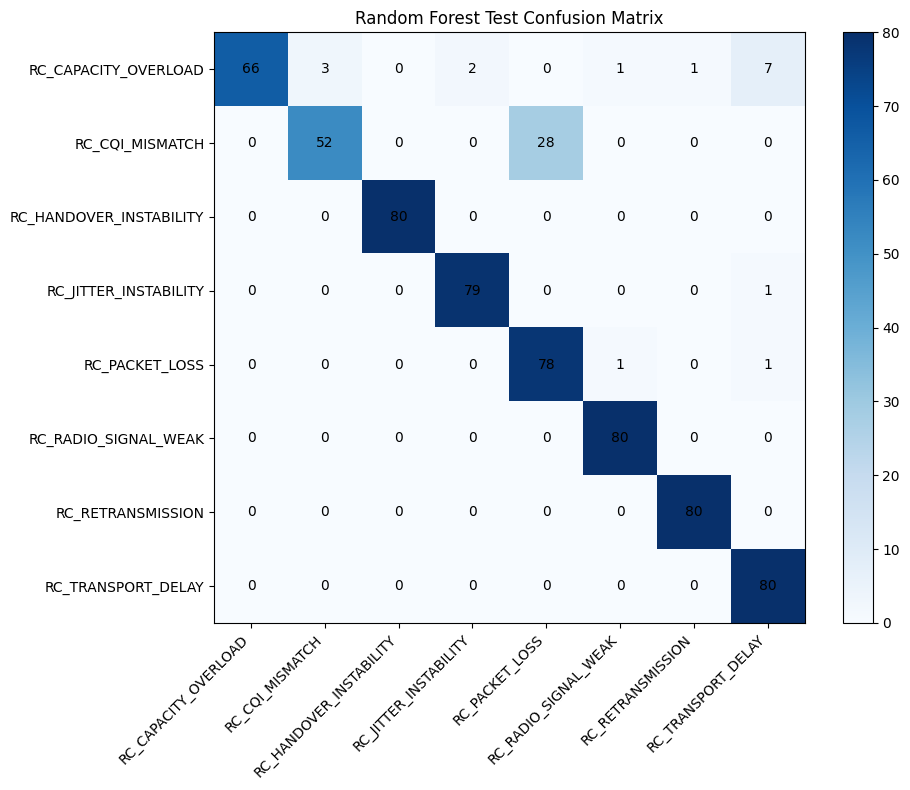

['outputs_8rc\\label_encoder_8rc.joblib']

In [7]:
def encode_labels(train, val, test):
    encoder = LabelEncoder()
    y_train = encoder.fit_transform(train["root_cause_label"])
    y_val = encoder.transform(val["root_cause_label"])
    y_test = encoder.transform(test["root_cause_label"])
    return encoder, y_train, y_val, y_test


train_df = feature_df[feature_df["split"] == "train"].copy()
val_df = feature_df[feature_df["split"] == "val"].copy()
test_df = feature_df[feature_df["split"] == "test"].copy()

label_encoder, y_train, y_val, y_test = encode_labels(train_df, val_df, test_df)
class_names = list(label_encoder.classes_)

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=18,
        min_samples_leaf=2,
        min_samples_split=4,
        class_weight="balanced_subsample",
        n_jobs=1,
        random_state=RANDOM_SEED,
    )),
])

banner("Training Random Forest")
start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start
print(f"Random Forest training time: {rf_train_time:.2f}s")


def supervised_metrics(model, X, y_true, split_name):
    pred = model.predict(X)
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "macro_f1": f1_score(y_true, pred, average="macro"),
        "weighted_f1": f1_score(y_true, pred, average="weighted"),
        "macro_precision": precision_score(y_true, pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, pred, average="macro", zero_division=0),
    }, pred


rf_rows = []
rf_predictions = {}
for split_name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    row, pred = supervised_metrics(rf_model, X, y, split_name)
    rf_rows.append(row)
    rf_predictions[split_name] = pred

rf_metrics_df = pd.DataFrame(rf_rows)
display(rf_metrics_df)
print("\nValidation classification report:")
print(classification_report(y_val, rf_predictions["val"], target_names=class_names, zero_division=0))
print("\nTest classification report:")
print(classification_report(y_test, rf_predictions["test"], target_names=class_names, zero_division=0))

rf_cm = confusion_matrix(y_test, rf_predictions["test"])
plt.figure(figsize=(10, 8))
plt.imshow(rf_cm, cmap="Blues")
plt.title("Random Forest Test Confusion Matrix")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
for i in range(rf_cm.shape[0]):
    for j in range(rf_cm.shape[1]):
        plt.text(j, i, rf_cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

rf_metrics_df.to_csv(OUTPUT_DIR / "rf_metrics_8rc.csv", index=False)
joblib.dump(rf_model, OUTPUT_DIR / "random_forest_8rc.joblib")
joblib.dump(label_encoder, OUTPUT_DIR / "label_encoder_8rc.joblib")

## 7. Build 10-Sample Sequence Windows

In [8]:
sequence_imputer = SimpleImputer(strategy="median")
sequence_imputer.fit(train_df[feature_cols])


def impute_sequence_source(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out[feature_cols] = sequence_imputer.transform(out[feature_cols])
    out[feature_cols] = out[feature_cols].replace([np.inf, -np.inf], 0).fillna(0)
    return out


train_seq_source = impute_sequence_source(train_df)
val_seq_source = impute_sequence_source(val_df)
test_seq_source = impute_sequence_source(test_df)


def make_sequences(df: pd.DataFrame, features, window_size=10):
    X_list, y_list, meta_rows = [], [], []
    ordered = df.sort_values(["sequence_group", "timestamp", "contract_row_index"], na_position="last")
    for group, group_df in ordered.groupby("sequence_group", sort=False):
        if len(group_df) < window_size:
            continue
        arr = group_df[features].to_numpy(dtype=np.float32)
        labels = group_df["root_cause_label"].to_numpy()
        row_ids = group_df["row_id"].to_numpy()
        for end in range(window_size, len(group_df) + 1):
            X_list.append(arr[end - window_size:end])
            y_list.append(labels[end - 1])
            meta_rows.append({
                "sequence_group": group,
                "end_row_id": row_ids[end - 1],
                "root_cause_label": labels[end - 1],
            })
    if not X_list:
        raise ValueError("No sequence windows were created. Check group sizes and window size.")
    return np.stack(X_list), np.array(y_list), pd.DataFrame(meta_rows)


seq_train_raw, seq_y_train_raw, seq_meta_train = make_sequences(train_seq_source, feature_cols, WINDOW_SIZE)
seq_val_raw, seq_y_val_raw, seq_meta_val = make_sequences(val_seq_source, feature_cols, WINDOW_SIZE)
seq_test_raw, seq_y_test_raw, seq_meta_test = make_sequences(test_seq_source, feature_cols, WINDOW_SIZE)

seq_scaler = StandardScaler()
seq_scaler.fit(seq_train_raw.reshape(-1, len(feature_cols)))


def scale_sequences(X):
    return seq_scaler.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape).astype(np.float32)


seq_train = scale_sequences(seq_train_raw)
seq_val = scale_sequences(seq_val_raw)
seq_test = scale_sequences(seq_test_raw)

banner("Sequence windows")
print("train", seq_train.shape, Counter(seq_y_train_raw))
print("val  ", seq_val.shape, Counter(seq_y_val_raw))
print("test ", seq_test.shape, Counter(seq_y_test_raw))

joblib.dump(seq_scaler, OUTPUT_DIR / "sequence_scaler_8rc.joblib")
joblib.dump(sequence_imputer, OUTPUT_DIR / "sequence_imputer_8rc.joblib")
np.savez_compressed(
    OUTPUT_DIR / "sequence_windows_8rc.npz",
    X_train=seq_train,
    y_train=seq_y_train_raw,
    X_val=seq_val,
    y_val=seq_y_val_raw,
    X_test=seq_test,
    y_test=seq_y_test_raw,
)


Sequence windows
train (1879, 10, 104) Counter({'RC_RADIO_SIGNAL_WEAK': 293, 'RC_CQI_MISMATCH': 248, 'RC_HANDOVER_INSTABILITY': 248, 'RC_PACKET_LOSS': 244, 'RC_CAPACITY_OVERLOAD': 226, 'RC_RETRANSMISSION': 215, 'RC_JITTER_INSTABILITY': 214, 'RC_TRANSPORT_DELAY': 191})
val   (442, 10, 104) Counter({'RC_CQI_MISMATCH': 62, 'RC_HANDOVER_INSTABILITY': 62, 'RC_PACKET_LOSS': 62, 'RC_RETRANSMISSION': 61, 'RC_RADIO_SIGNAL_WEAK': 53, 'RC_JITTER_INSTABILITY': 49, 'RC_CAPACITY_OVERLOAD': 48, 'RC_TRANSPORT_DELAY': 45})
test  (496, 10, 104) Counter({'RC_PACKET_LOSS': 71, 'RC_RADIO_SIGNAL_WEAK': 71, 'RC_CQI_MISMATCH': 62, 'RC_HANDOVER_INSTABILITY': 62, 'RC_RETRANSMISSION': 62, 'RC_TRANSPORT_DELAY': 62, 'RC_CAPACITY_OVERLOAD': 53, 'RC_JITTER_INSTABILITY': 53})


## 8. Train GRU Autoencoder

In [9]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except Exception as exc:
    raise RuntimeError("PyTorch is required for the GRU autoencoder.") from exc


def select_device():
    if not torch.cuda.is_available():
        return torch.device("cpu")
    try:
        test_gru = nn.GRU(4, 4, batch_first=True).cuda()
        test_x = torch.randn(2, 3, 4, device="cuda")
        with torch.no_grad():
            _ = test_gru(test_x)
        del test_gru, test_x
        torch.cuda.empty_cache()
        return torch.device("cuda")
    except Exception:
        return torch.device("cpu")


DEVICE = select_device()
torch.manual_seed(RANDOM_SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(RANDOM_SEED)
print("Using device:", DEVICE)


class GRUAutoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64, latent_dim: int = 32):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.encoder = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.to_latent = nn.Linear(hidden_dim, latent_dim)
        self.from_latent = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        _, h_n = self.encoder(x)
        return self.to_latent(h_n[-1])

    def forward(self, x):
        seq_len = x.size(1)
        z = self.encode(x)
        dec_init = self.from_latent(z)
        dec_seq = dec_init.unsqueeze(1).repeat(1, seq_len, 1)
        dec_out, _ = self.decoder(dec_seq)
        return self.output_layer(dec_out)


def make_loader(X, batch_size, shuffle):
    tensor = torch.tensor(X, dtype=torch.float32)
    return DataLoader(TensorDataset(tensor), batch_size=batch_size, shuffle=shuffle)


train_loader = make_loader(seq_train, GRU_BATCH_SIZE, True)
val_loader = make_loader(seq_val, GRU_BATCH_SIZE, False)

gru_model = GRUAutoencoder(input_dim=len(feature_cols), hidden_dim=64, latent_dim=32).to(DEVICE)
optimizer = torch.optim.Adam(gru_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()


def epoch_loss(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total = 0.0
    count = 0
    for (batch,) in loader:
        batch = batch.to(DEVICE)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
        recon = model(batch)
        loss = criterion(recon, batch)
        if is_train:
            loss.backward()
            optimizer.step()
        total += loss.item() * len(batch)
        count += len(batch)
    return total / max(count, 1)


banner("Training GRU autoencoder")
best_state = None
best_val_loss = float("inf")
best_epoch = -1
bad_epochs = 0
history = []
start = time.time()

for epoch in range(1, GRU_EPOCHS + 1):
    train_loss = epoch_loss(gru_model, train_loader, optimizer)
    val_loss = epoch_loss(gru_model, val_loader, optimizer=None)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    print(f"epoch={epoch:02d} train_loss={train_loss:.5f} val_loss={val_loss:.5f}")
    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in gru_model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
    if bad_epochs >= GRU_PATIENCE:
        print("Early stopping.")
        break

gru_train_time = time.time() - start
gru_model.load_state_dict(best_state)
gru_model.eval()
print(f"Best epoch: {best_epoch}, best val loss: {best_val_loss:.5f}, train time: {gru_train_time:.2f}s")

pd.DataFrame(history).to_csv(OUTPUT_DIR / "gru_training_history_8rc.csv", index=False)
torch.save(
    {
        "state_dict": gru_model.state_dict(),
        "input_dim": len(feature_cols),
        "hidden_dim": 64,
        "latent_dim": 32,
        "window_size": WINDOW_SIZE,
        "feature_cols": feature_cols,
    },
    OUTPUT_DIR / "gru_autoencoder_8rc.pt",
)

Using device: cpu



Training GRU autoencoder


epoch=01 train_loss=0.90810 val_loss=3.28786


epoch=02 train_loss=0.66559 val_loss=3.18270


epoch=03 train_loss=0.56478 val_loss=3.09404


...

epoch=14 train_loss=0.46725 val_loss=2.93973


epoch=15 train_loss=0.46518 val_loss=2.93617


epoch=16 train_loss=0.46327 val_loss=2.93248


epoch=17 train_loss=0.46158 val_loss=2.92928


epoch=18 train_loss=0.46007 val_loss=2.92750
Best epoch: 18, best val loss: 2.92750, train time: 14.00s


## 9. Build FAISS-Compatible Prototype Retrieval

In [10]:
def encode_latents(model, X, batch_size=256):
    loader = make_loader(X, batch_size, False)
    latents = []
    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            z = model.encode(batch.to(DEVICE)).detach().cpu().numpy()
            latents.append(z)
    return np.vstack(latents).astype("float32")


Z_train = encode_latents(gru_model, seq_train)
Z_val = encode_latents(gru_model, seq_val)
Z_test = encode_latents(gru_model, seq_test)


def rf_endpoint_probabilities(meta_df: pd.DataFrame, source_df: pd.DataFrame) -> np.ndarray:
    source_lookup = source_df.drop_duplicates("row_id").set_index("row_id")
    endpoint_features = source_lookup.loc[meta_df["end_row_id"].to_numpy(), feature_cols]
    return rf_model.predict_proba(endpoint_features).astype("float32")


prototype_latent_scaler = StandardScaler()
prototype_latent_scaler.fit(Z_train)

RF_PROBABILITY_VECTOR_WEIGHT = 8.0
P_train = rf_endpoint_probabilities(seq_meta_train, train_seq_source)
P_val = rf_endpoint_probabilities(seq_meta_val, val_seq_source)
P_test = rf_endpoint_probabilities(seq_meta_test, test_seq_source)


def build_prototype_vectors(latents: np.ndarray, rf_probabilities: np.ndarray) -> np.ndarray:
    scaled_latents = prototype_latent_scaler.transform(latents).astype("float32")
    return np.hstack([
        scaled_latents,
        (rf_probabilities * RF_PROBABILITY_VECTOR_WEIGHT).astype("float32"),
    ]).astype("float32")


PV_train = build_prototype_vectors(Z_train, P_train)
PV_val = build_prototype_vectors(Z_val, P_val)
PV_test = build_prototype_vectors(Z_test, P_test)

prototype_label_encoder = LabelEncoder()
proto_y_train = prototype_label_encoder.fit_transform(seq_y_train_raw)
proto_y_val = prototype_label_encoder.transform(seq_y_val_raw)
proto_y_test = prototype_label_encoder.transform(seq_y_test_raw)
proto_class_names = list(prototype_label_encoder.classes_)


class PrototypeIndex:
    def __init__(self, vectors: np.ndarray, labels: np.ndarray, class_names, k: int = 5):
        self.vectors = np.ascontiguousarray(vectors.astype("float32"))
        self.labels = np.asarray(labels)
        self.class_names = list(class_names)
        self.k = k
        self.backend = None
        self.index = None
        try:
            import faiss  # type: ignore
            self.faiss = faiss
            self.index = faiss.IndexFlatL2(self.vectors.shape[1])
            self.index.add(self.vectors)
            self.backend = "faiss_IndexFlatL2"
        except Exception:
            self.faiss = None
            self.index = NearestNeighbors(n_neighbors=k, metric="euclidean")
            self.index.fit(self.vectors)
            self.backend = "sklearn_exact_fallback"

    def search(self, queries: np.ndarray, k: int = None):
        k = k or self.k
        queries = np.ascontiguousarray(queries.astype("float32"))
        if self.backend == "faiss_IndexFlatL2":
            distances, indices = self.index.search(queries, k)
        else:
            distances, indices = self.index.kneighbors(queries, n_neighbors=k, return_distance=True)
        neighbor_labels = self.labels[indices]
        pred = np.array([Counter(row).most_common(1)[0][0] for row in neighbor_labels])
        return distances, indices, neighbor_labels, pred

    def save(self, output_dir: Path):
        np.savez_compressed(
            output_dir / "prototype_vectors_8rc.npz",
            vectors=self.vectors,
            labels=self.labels,
            class_names=np.array(self.class_names, dtype=object),
        )
        if self.backend == "faiss_IndexFlatL2":
            self.faiss.write_index(self.index, str(output_dir / "faiss_prototype_index_8rc.faiss"))


proto_index = PrototypeIndex(PV_train, proto_y_train, proto_class_names, k=5)
print("Prototype backend:", proto_index.backend)
print("Prototype vector dim:", PV_train.shape[1], "(GRU latent + weighted RF posterior)")


def topk_hit_rate(y_true, neighbor_labels, k):
    return float(np.mean([true in row[:k] for true, row in zip(y_true, neighbor_labels)]))


def proto_metrics(Z, y_true, split_name):
    start = time.time()
    distances, indices, neighbor_labels, pred = proto_index.search(Z, k=5)
    elapsed = time.time() - start
    return {
        "split": split_name,
        "backend": proto_index.backend,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "macro_f1": f1_score(y_true, pred, average="macro"),
        "weighted_f1": f1_score(y_true, pred, average="weighted"),
        "top3_hit_rate": topk_hit_rate(y_true, neighbor_labels, 3),
        "top5_hit_rate": topk_hit_rate(y_true, neighbor_labels, 5),
        "search_time_sec": elapsed,
    }, pred, neighbor_labels, distances


proto_rows = []
proto_outputs = {}
for split_name, Z, y in [("train", PV_train, proto_y_train), ("val", PV_val, proto_y_val), ("test", PV_test, proto_y_test)]:
    row, pred, neighbors, distances = proto_metrics(Z, y, split_name)
    proto_rows.append(row)
    proto_outputs[split_name] = {
        "pred": pred,
        "neighbors": neighbors,
        "distances": distances,
    }

proto_metrics_df = pd.DataFrame(proto_rows)
display(proto_metrics_df)
print("\nPrototype test classification report:")
print(classification_report(proto_y_test, proto_outputs["test"]["pred"], target_names=proto_class_names, zero_division=0))

proto_index.save(OUTPUT_DIR)
joblib.dump(prototype_label_encoder, OUTPUT_DIR / "prototype_label_encoder_8rc.joblib")
joblib.dump(prototype_latent_scaler, OUTPUT_DIR / "prototype_latent_scaler_8rc.joblib")
proto_metrics_df.to_csv(OUTPUT_DIR / "prototype_metrics_8rc.csv", index=False)

Prototype backend: sklearn_exact_fallback
Prototype vector dim: 40 (GRU latent + weighted RF posterior)


  File "C:\Users\amani\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\amani\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __ini

,split,backend,accuracy,balanced_accuracy,macro_f1,weighted_f1,top3_hit_rate,top5_hit_rate,search_time_sec
0,train,sklearn_exact_fallback,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.014298
1,val,sklearn_exact_fallback,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.013523
2,test,sklearn_exact_fallback,0.816532,0.812337,0.804562,0.799047,0.870968,0.885081,0.014129



Prototype test classification report:
                         precision    recall  f1-score   support

   RC_CAPACITY_OVERLOAD       1.00      0.81      0.90        53
        RC_CQI_MISMATCH       1.00      0.32      0.49        62
RC_HANDOVER_INSTABILITY       1.00      0.98      0.99        62
  RC_JITTER_INSTABILITY       1.00      0.94      0.97        53
         RC_PACKET_LOSS       0.62      0.99      0.77        71
   RC_RADIO_SIGNAL_WEAK       0.66      1.00      0.80        71
      RC_RETRANSMISSION       1.00      0.45      0.62        62
     RC_TRANSPORT_DELAY       0.83      1.00      0.91        62

               accuracy                           0.82       496
              macro avg       0.89      0.81      0.80       496
           weighted avg       0.88      0.82      0.80       496



## 10. Deployment Diagnostic Contract Output

In [11]:
def rf_topk(model, X_row: pd.DataFrame, label_encoder: LabelEncoder, k=3):
    proba = model.predict_proba(X_row)[0]
    order = np.argsort(proba)[::-1][:k]
    return [
        {"root_cause": label_encoder.inverse_transform([idx])[0], "probability": float(proba[idx])}
        for idx in order
    ]


def prototype_topk_from_sequence(raw_sequence_features: np.ndarray, k=5):
    scaled = scale_sequences(raw_sequence_features[np.newaxis, :, :])
    latent = encode_latents(gru_model, scaled)
    endpoint_df = pd.DataFrame([raw_sequence_features[-1]], columns=feature_cols)
    endpoint_proba = rf_model.predict_proba(endpoint_df).astype("float32")
    prototype_vector = build_prototype_vectors(latent, endpoint_proba)
    distances, indices, neighbor_labels, pred = proto_index.search(prototype_vector, k=k)
    labels = prototype_label_encoder.inverse_transform(neighbor_labels[0])
    return [
        {"root_cause": label, "distance": float(distances[0, i])}
        for i, label in enumerate(labels)
    ]


def make_diagnostic_contract(row_df: pd.DataFrame, sequence_features: np.ndarray = None):
    if len(row_df) != 1:
        raise ValueError("row_df must contain exactly one engineered feature row.")
    top3 = rf_topk(rf_model, row_df[feature_cols], label_encoder, k=3)
    primary = top3[0]["root_cause"]
    contract = ROOT_CAUSE_CONTRACTS[primary]
    result = {
        "root_cause": primary,
        "confidence": top3[0]["probability"],
        "rf_top3": top3,
        "contract_description": contract["description"],
        "primary_evidence_fields": contract["primary_evidence"],
    }
    if sequence_features is not None:
        result["prototype_neighbors"] = prototype_topk_from_sequence(sequence_features, k=5)
        result["prototype_backend"] = proto_index.backend
    return result


example_row = test_df.iloc[[0]].copy()
example_sequence = seq_test_raw[0]
example_contract = make_diagnostic_contract(example_row, sequence_features=example_sequence)
print(json.dumps(example_contract, indent=2))

with open(OUTPUT_DIR / "example_diagnostic_contract_8rc.json", "w", encoding="utf-8") as f:
    json.dump(example_contract, f, indent=2)

{
  "root_cause": "RC_CAPACITY_OVERLOAD",
  "confidence": 0.439274202253186,
  "rf_top3": [
    {
      "root_cause": "RC_CAPACITY_OVERLOAD",
      "probability": 0.439274202253186
    },
    {
      "root_cause": "RC_CQI_MISMATCH",
      "probability": 0.2361613875369433
    },
    {
      "root_cause": "RC_RETRANSMISSION",
      "probability": 0.12372016578486114
    }
  ],
  "contract_description": "Capacity or congestion pressure: low throughput, high queueing, high utilization, and connection pressure.",
  "primary_evidence_fields": [
    "throughput_mbps",
    "bandwidth_util_pct",
    "queue_length",
    "active_connections"
  ],
  "prototype_neighbors": [
    {
      "root_cause": "RC_CAPACITY_OVERLOAD",
      "distance": 3.7872531414031982
    },
    {
      "root_cause": "RC_CAPACITY_OVERLOAD",
      "distance": 3.8391504287719727
    },
    {
      "root_cause": "RC_CAPACITY_OVERLOAD",
      "distance": 3.918948173522949
    },
    {
      "root_cause": "RC_CAPACITY_OVERLOAD

## 11. Save Final Deployment Summary

In [12]:
rf_importances = rf_model.named_steps["classifier"].feature_importances_
importance_df = (
    pd.DataFrame({"feature": feature_cols, "importance": rf_importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(importance_df.head(25))
importance_df.to_csv(OUTPUT_DIR / "rf_feature_importance_8rc.csv", index=False)

summary = {
    "benchmark_type": "8-root-cause deployment contract benchmark",
    "baseline_report_scope": "Original report validated 2 real-data classes; this notebook extends to 8 deployment contracts with explicit augmentation provenance.",
    "root_causes": list(ROOT_CAUSE_CONTRACTS.keys()),
    "feature_count": len(feature_cols),
    "window_size": WINDOW_SIZE,
    "target_counts_per_split": TARGET_COUNTS,
    "random_forest": {
        "artifact": "random_forest_8rc.joblib",
        "train_time_sec": rf_train_time,
        "metrics": rf_metrics_df.to_dict(orient="records"),
    },
    "gru_autoencoder": {
        "artifact": "gru_autoencoder_8rc.pt",
        "best_epoch": best_epoch,
        "best_val_loss": float(best_val_loss),
        "train_time_sec": gru_train_time,
    },
    "prototype_retrieval": {
        "backend": proto_index.backend,
        "prototype_vector": "GRU latent concatenated with weighted Random Forest posterior",
        "rf_probability_vector_weight": RF_PROBABILITY_VECTOR_WEIGHT,
        "faiss_index_artifact": "faiss_prototype_index_8rc.faiss" if proto_index.backend == "faiss_IndexFlatL2" else None,
        "fallback_artifact": "prototype_vectors_8rc.npz",
        "metrics": proto_metrics_df.to_dict(orient="records"),
    },
    "artifact_directory": str(OUTPUT_DIR.resolve()),
}

with open(OUTPUT_DIR / "deployment_summary_8rc.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

banner("Saved deployment artifacts")
for path in sorted(OUTPUT_DIR.glob("*")):
    print(path.name)

,feature,importance
0,queue_length_rollmean_5,0.049057
1,bler_pct_model_rollmean_5,0.045946
2,queue_length_rollmean_3,0.040974
3,packet_loss_pct_rollmean_5,0.040763
4,latency_ms_rollmean_5,0.039442
5,bler_mcs_stress,0.038105
6,packet_loss_pct_rollmean_3,0.035514
7,handover_event,0.035356
8,jitter_ms_rollmean_5,0.032137
9,packet_loss_pct,0.031683



Saved deployment artifacts
benchmark_8rc_engineered.csv
deployment_summary_8rc.json
example_diagnostic_contract_8rc.json
feature_columns_8rc.json
gru_autoencoder_8rc.pt
gru_training_history_8rc.csv
label_encoder_8rc.joblib
prototype_label_encoder_8rc.joblib
prototype_latent_scaler_8rc.joblib
prototype_latents_8rc.npz
prototype_metrics_8rc.csv
prototype_vectors_8rc.npz
random_forest_8rc.joblib
rf_feature_importance_8rc.csv
rf_metrics_8rc.csv
root_cause_contracts_8rc.json
sequence_imputer_8rc.joblib
sequence_scaler_8rc.joblib
sequence_windows_8rc.npz


## Interpretation Notes

- The original report remains valid as a conservative real-data benchmark for the two robust classes.
- This notebook is the deployment-extension benchmark. It intentionally introduces controlled contract augmentation so the deployed agent can emit all 8 required root-cause contracts.
- Any metrics on augmented validation/test rows should be interpreted as **contract conformance**, not as proof that all 8 classes were naturally observed at production frequency.
- In a Linux deployment image, install `faiss-cpu` so the prototype backend saves and serves a native FAISS index. On Windows, the notebook falls back to exact `NearestNeighbors` with the same search interface because official FAISS wheels are generally unavailable.